<h1><font color="#113D68" size=6>Deep Learning con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 6. Redes Neuronales Recurrentes</font></h1>

<h1><font color="#113D68" size=4>3. Predicción con LSTM</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. LSTM para regresión](#section1)
    * [1.1. Cargar el dataset](#section1.1)
    * [1.2. Normalización de datos](#section1.2)
    * [1.3. Train/Test](#section1.3)
    * [1.4. Creamos el dataset para una serie temporal](#section1.4)
    * [1.5. Transformar las muestras](#section1.5)
    * [1.6. Diseño de LSTM](#section1.6)
    * [1.7. Resultados](#section1.7)
* [2. LSTM usando ventana](#section2)
* [3. LSTM con pasos de tiempo](#section3)
* [4. LSTM con memoria entre batchs](#section4)
    * [4.1. Generar estado en train](#section4.1)
    * [4.2. Diseño de LSTM](#section4.2)
* [5. Stacked LSTM con memoria entre batchs](#section5)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

Los problemas de predicción de series de tiempo son un tipo difícil de problema de modelado predictivo. A diferencia del modelo predictivo de regresión, las series de tiempo también agregan la complejidad de una dependencia de secuencia entre las variables de entrada. Un tipo poderoso de red neuronal diseñada para manejar la dependencia de secuencia se denomina redes neuronales recurrentes. La red LSTM es un tipo de red neuronal recurrente que se utiliza en el Deep Learning porque se pueden entrenar con éxito arquitecturas muy grande

Después de completar esta clase, sabrá cómo implementar y desarrollar redes LSTM para sus propios problemas de predicción de series de tiempo y otros problemas de secuencia más generales. Lo sabrás:
* Cómo desarrollar redes LSTM para un problema de predicción de series de tiempo enmarcado como regresión.
* Cómo desarrollar redes LSTM para un problema de predicción de series de tiempo usando una ventana para características y pasos de tiempo.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch documentation: [`torch.utils.data`](https://pytorch.org/docs/stable/data.html).

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. LSTM para regresión</font>

- Problema: Predicción de pasajeros de aerolíneas internacionales
  - Formulado como un problema de regresión

- Características de la serie temporal:
  - 144 pasos de tiempo

  - Tendencia al alza visible

  - Periodicidad correspondiente a vacaciones de verano del hemisferio norte

- Observaciones del gráfico:
  - Patrón creciente a lo largo del tiempo

  - Picos estacionales recurrentes

- Preprocesamiento típico (omitido en este proyecto):
  1. "Destrendear" la serie (eliminar componente de tendencia lineal)

  2. Normalización de los datos

- Simplificación del proyecto:
  - No se realiza el preprocesamiento estándar

  - Enfoque en el modelado directo de los datos brutos

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [Air Passengers](https://www.kaggle.com/chirag19/air-passengers)

<a id="section1.1"></a>
# <font color="#004D7F" size=5>1.1. Cargar el dataset</font>

Este ejemplo reutilizará la misma carga y preparación de datos del capítulo anterior.

In [1]:
# Descarga de datos (necesario en Colab): se guardan en ./Datasets
import os, urllib.request

os.makedirs('Datasets', exist_ok=True)
urls = {
    'international-airline-passengers.csv':
        'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv',
}
for nombre, url in urls.items():
    if not os.path.exists(f'Datasets/{nombre}'):
        urllib.request.urlretrieve(url, f'Datasets/{nombre}')

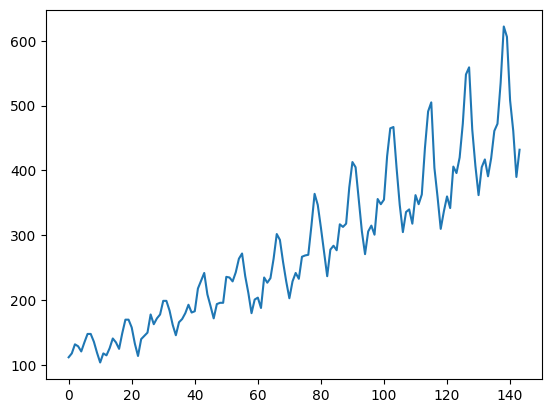

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

df = pd.read_csv('Datasets/international-airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')  # array (144, 1)

plt.plot(timeseries)
plt.show()

<a id="section1.2"></a>
# <font color="#004D7F" size=5>1.2. Datos de Train/Test</font>

- Dividimos en entrenamiento y test. 
- A diferencia de otros conjuntos de datos, normalmente los datos de series temporales se dividen sin mezclar. 
- Esto se puede hacer fácilmente con un array de NumPy.

In [3]:
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]  # sin mezclar: el orden temporal importa

<a id="section1.3"></a>
# <font color="#004D7F" size=5>1.3. Transformar dataset a serie temporal</font>

el enfoque de ventana deslizante es fundamental para preparar datos de series temporales para su uso en modelos de aprendizaje profundo, permitiendo una predicción efectiva basada en patrones históricos.

- Predicción de series temporales usando ventanas:
  - Se predice para el tiempo `t+1` (o más allá)

  - Basado en datos desde `t-w` hasta `t`

  - `w` es el tamaño de la ventana o período de retroceso

- Concepto de ventana deslizante:
  - Permite crear múltiples ventanas superpuestas en series 
  
  - Maximiza el uso de los datos disponibles

- Función para generar conjunto de datos de ventanas fijas:
  - Convierte la serie temporal en múltiples ventanas

  - Resultado en tensores de PyTorch para uso en modelos

- Características de la función:
  - Entrada: Serie temporal y tamaño de ventana

  - Salida: Conjunto de ventanas superpuestas

- Ventajas de este enfoque:
  - Permite al modelo aprender patrones temporales

  - Facilita el entrenamiento con datos secuenciales

- Consideraciones:
  - Elección adecuada del tamaño de ventana

  - Balance entre contexto histórico y capacidad predictiva

In [4]:
def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset

    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]  # misma ventana desplazada 1 paso
        X.append(feature)
        y.append(target)
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))

<a id="section1.4"></a>
# <font color="#004D7F" size=5>1.4. Crear el dataset para una serie temporal</font>

Este enfoque permite una preparación eficiente de datos de series temporales para su uso en modelos de aprendizaje profundo, facilitando el análisis de patrones temporales y la predicción de valores futuros.

- Función diseñada para aplicar ventanas a series temporales:
  - Predice un paso de tiempo hacia el futuro inmediato

  - Convierte serie temporal en tensor 3D **muestra de ventana, pasos de tiempo, características** _(window sample, time steps, features)_
    1. Muestra de 
    
    2. Pasos de tiempo
    
    3. Características

- Generación de ventanas:
  - Serie temporal de _L_ pasos puede generar aproximadamente _L_ ventanas

  - Cada ventana comienza en un paso de tiempo diferente

- Estructura de una ventana:
  - Múltiples pasos de tiempo consecutivos
  
  - Cada paso de tiempo puede tener múltiples características
  
  - En este caso: solo una característica por paso de tiempo

- Diseño intencional de características y objetivos:

  - Misma forma para ambos

  - Ejemplo con ventana de 3 pasos:

    - Característica: serie desde _t_ hasta _t+2_

    - Objetivo: serie desde _t+1_ hasta _t+3_

  - Foco en _t+3_, pero _t+1_ y _t+2_ útiles para entrenamiento

- Formato de entrada y salida:

  - Entrada: Array 2D

  - Salida de create_dataset(): Tensor 3D

- Ejemplo con `lookback=1`:
  - Permite verificar la forma del tensor de salida

  - Demuestra la transformación de 2D a 3D

In [5]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1, 1]) torch.Size([95, 1, 1])
torch.Size([47, 1, 1]) torch.Size([47, 1, 1])


<a id="section1.5"></a>
# <font color="#004D7F" size=5>1.5. Diseño de LSTM</font>

Este diseño proporciona una base sólida para la predicción de series temporales con LSTM, permitiendo ajustes y optimizaciones futuras según las características específicas del problema y los datos.

- Construcción del modelo LSTM para predicción de series temporales:

- Consideraciones con `lookback=1`:

  - Precisión probablemente baja

  - Útil para demostrar la estructura del modelo LSTM

- Estructura del modelo:

  - Implementado como una clase

  - Componentes principales:
    1. Capa LSTM

    2. Capa totalmente conectada (_fully-connected_)

- Características de `nn.LSTM()`:
  - Salida es una tupla

  - Primer elemento: estados ocultos por cada paso de tiempo
  
  - Segundo elemento: memoria y estados ocultos de la celda. Al no utilizarse se pondrá `_`

- Configuración de la capa LSTM:
  - Opción `batch_first=True`
    - De forma predeterminada, las LSTMs en PyTorch esperan que la entrada tenga las dimensiones en el orden _(sequence_length, batch_size, input_size)_, es decir, primero la longitud de la secuencia, luego el tamaño del lote (batch), y finalmente el tamaño de las características de entrada. 

    - Sin embargo, cuando estableces `batch_first=True`, PyTorch espera las entradas en el orden _(batch_size, sequence_length, input_size)_, poniendo el tamaño del lote en primer lugar.

- Procesamiento post-LSTM:
  - Capa totalmente conectada

  - Produce un resultado de regresión

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`nn.LSTM`](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

In [6]:
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm(x)  # salida en cada paso de tiempo: (batch, lookback, 50)
        x = self.linear(x)
        return x

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Entrenamiento de la serie temporal</font>

- Dado que se trata de un problema de regresión, se elige el MSE (Error Cuadrático Medio) como función de pérdida

- El optimizador Adam. 

-Los tensores de PyTorch se combinan en un conjunto de datos utilizando *torch.utils.data.TensorDataset()* 

- El batch para el entrenamiento es proporcionado por un *DataLoader*. 

- El rendimiento del modelo se evalúa una vez cada 100 épocas, tanto en el conjunto de entrenamiento como en el conjunto de prueba:

In [7]:
model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 100 != 0:  # validar solo cada 100 épocas
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Época %d: RMSE en train %.4f, RMSE en test %.4f" % (epoch, train_rmse, test_rmse))

/tmp/ipykernel_455129/683832172.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_rmse = np.sqrt(loss_fn(y_pred, y_train))
/tmp/ipykernel_455129/683832172.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_rmse = np.sqrt(loss_fn(y_pred, y_test))


Época 0: RMSE en train 225.8316, RMSE en test 422.2250


Época 100: RMSE en train 183.7614, RMSE en test 378.1747


Época 200: RMSE en train 150.1230, RMSE en test 341.8065


Época 300: RMSE en train 121.2831, RMSE en test 308.8076


...

Época 1500: RMSE en train 24.1484, RMSE en test 109.7682


Época 1600: RMSE en train 23.9580, RMSE en test 105.8204


Época 1700: RMSE en train 23.6508, RMSE en test 103.4738


Época 1800: RMSE en train 23.5657, RMSE en test 100.4727


Época 1900: RMSE en train 23.8193, RMSE en test 98.0771


Un RMSE de 100 significa que, en promedio, la predicción y el objetivo real estarán desviados por un valor de 100 (es decir, 100,000 pasajeros en este conjunto de datos).

Veamos la gráfica.
- La función `np.ones_like(timeseries) * np.nan` crea un arreglo del mismo tamaño y forma que timeseries, pero lleno de valores `np.nan` en lugar de valores válidos. Este arreglo de `NaN` sirve como base para asignar valores en algunas posiciones específicas, dejando el resto vacío (o no definido).

- La línea `y_pred = y_pred[:, -1, :]` extrae las predicciones de la última celda temporal de la salida de la red LSTM:

    1. **Predicción de la LSTM**: 

    - La LSTM en el modelo genera una salida de la forma `(batch_size, sequence_length, hidden_size)`. Esta salida contiene una predicción para cada paso en la secuencia de entrada.
    
    2. **Uso de `[:, -1, :]`**:

    - `y_pred[:, -1, :]` selecciona solo la última predicción de la secuencia para cada muestra en el lote (batch), ya que `-1` indica el último paso de tiempo en la dimensión `sequence_length`.

    - Esto da una forma reducida, `(batch_size, hidden_size)`, que es la salida final de la LSTM correspondiente al último paso de cada secuencia de entrada.

    3. **Almacenamiento de las Predicciones**:

    - En el contexto de `train_plot[lookback:train_size] = model(X_train)[:, -1, :]`, las predicciones del último paso de tiempo de cada secuencia en el conjunto de entrenamiento (`X_train`) se guardan en el arreglo `train_plot` en posiciones específicas.

    - Esto se hace para que el gráfico solo muestre las predicciones en las posiciones que corresponden al conjunto de entrenamiento, mientras que `test_plot[train_size+lookback:len(timeseries)]` hace lo mismo para el conjunto de prueba.

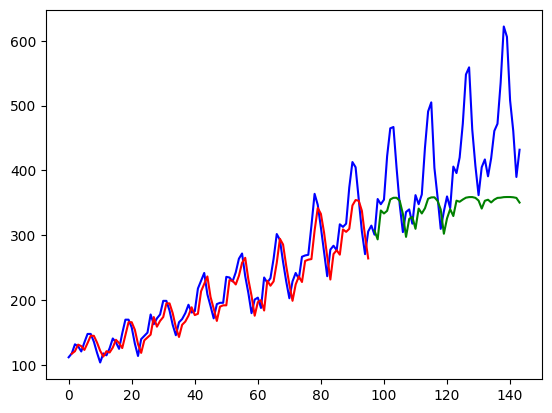

In [8]:
with torch.no_grad():
    train_plot = np.ones_like(timeseries) * np.nan  # desplazar las predicciones de train para graficar
    y_pred = model(X_train)
    y_pred =y_pred[:, -1, :]  # nos quedamos con la predicción del último paso
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]

plt.plot(timeseries, c='b')
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. LSTM con loopback = 4</font>

Resumiendo, a continuación se presenta el código completo, excepto que el parámetro *lookback* se establece en 4 esta vez. Ejecutar el código anterior producirá el gráfico a continuación. Tanto por la medida de RMSE impresa como por el gráfico, puedes notar que el modelo ahora puede hacerlo mejor en el conjunto de prueba.

/tmp/ipykernel_455129/2169226396.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_rmse = np.sqrt(loss_fn(y_pred, y_train))
/tmp/ipykernel_455129/2169226396.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_rmse = np.sqrt(loss_fn(y_pred, y_test))


Época 0: RMSE en train 226.1931, RMSE en test 425.4499


Época 100: RMSE en train 180.8769, RMSE en test 377.9624


Época 200: RMSE en train 145.7194, RMSE en test 339.7241


Época 300: RMSE en train 116.5172, RMSE en test 305.6577


...

Época 1500: RMSE en train 21.1241, RMSE en test 89.6973


Época 1600: RMSE en train 20.6289, RMSE en test 86.2531


Época 1700: RMSE en train 20.3677, RMSE en test 82.5466


Época 1800: RMSE en train 20.0369, RMSE en test 80.3584


Época 1900: RMSE en train 19.8324, RMSE en test 78.5028


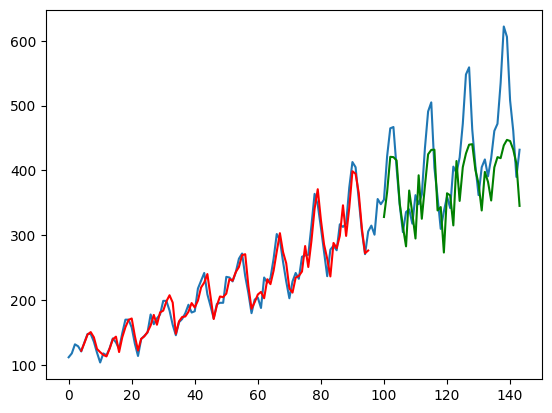

In [9]:
lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)

model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 100 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Época %d: RMSE en train %.4f, RMSE en test %.4f" % (epoch, train_rmse, test_rmse))

with torch.no_grad():
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]

plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()


Esto también explica por qué la función `create_dataset()` está diseñada de esta manera: 
- Cuando al modelo se le da una serie temporal de tiempo $t$ a $t+3$ (con `lookback=4`), su salida es la predicción de $t+1$ a $t+4$. Sin embargo, $t+1$ a $t+3$ también se conocen a partir de la entrada. 

- Al utilizar estos en la función de pérdida, el modelo efectivamente recibe más pistas para entrenarse. Este diseño no siempre es adecuado, pero puedes ver que es útil en este ejemplo particular.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>